In [89]:
import numpy as np
import matplotlib.pyplot as plt
import csv
from pathlib import Path
import mcstasscript as ms
from scipy.optimize import curve_fit  
import re
from math import ceil
from matplotlib.patches import Rectangle

Sample run directory: /Users/christian/Documents/Study/bachelor_project/geometry_optimization/PSI_instrument/PSI_settings_1e11
Parsed 14 of 14 .dat files
Beamstop enabled:
  sample_spherical_monitor: 6 deg x 10 deg centered at (0.0, 0.0)
  sample_cylinder_monitor:  10 deg x 0.2 m centered at (0.0, 0.0)
Monitor totals:
  BackEndMonitor.dat             total=28889.1  component=BackEndMonitor
  EndOfInsertPSD.dat             total=1.74815e+09  component=EndOfInsertPSD
  ExitC1.dat                     total=9.08567e+08  component=C1End
  ExitE2.dat                     total=1.39029e+09  component=E2PSD
  ExitE3a.dat                    total=8.82068e+08  component=E3aEnd
  ExitE3b.dat                    total=6.20194e+08  component=E3bEnd
  sample_cylinder_monitor.dat    total=4.46217e+07  component=sample_cylinder_monitor
  sample_cylinder_monitor_scattered.dat total=1.71709e+06  component=sample_cylinder_monitor_scattered
  sample_flux_after_unscattered.dat total=4.29046e+07  component=sa

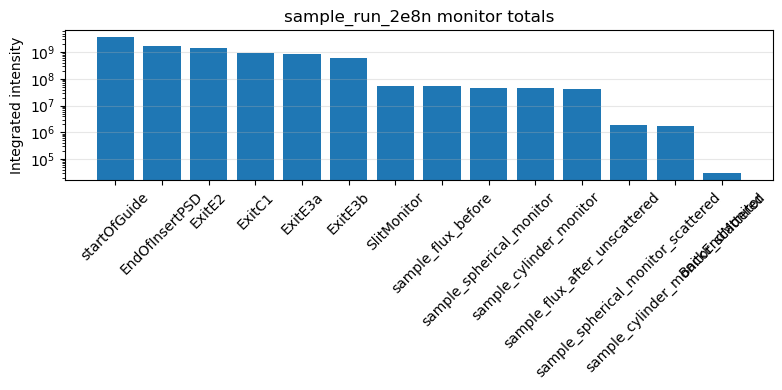

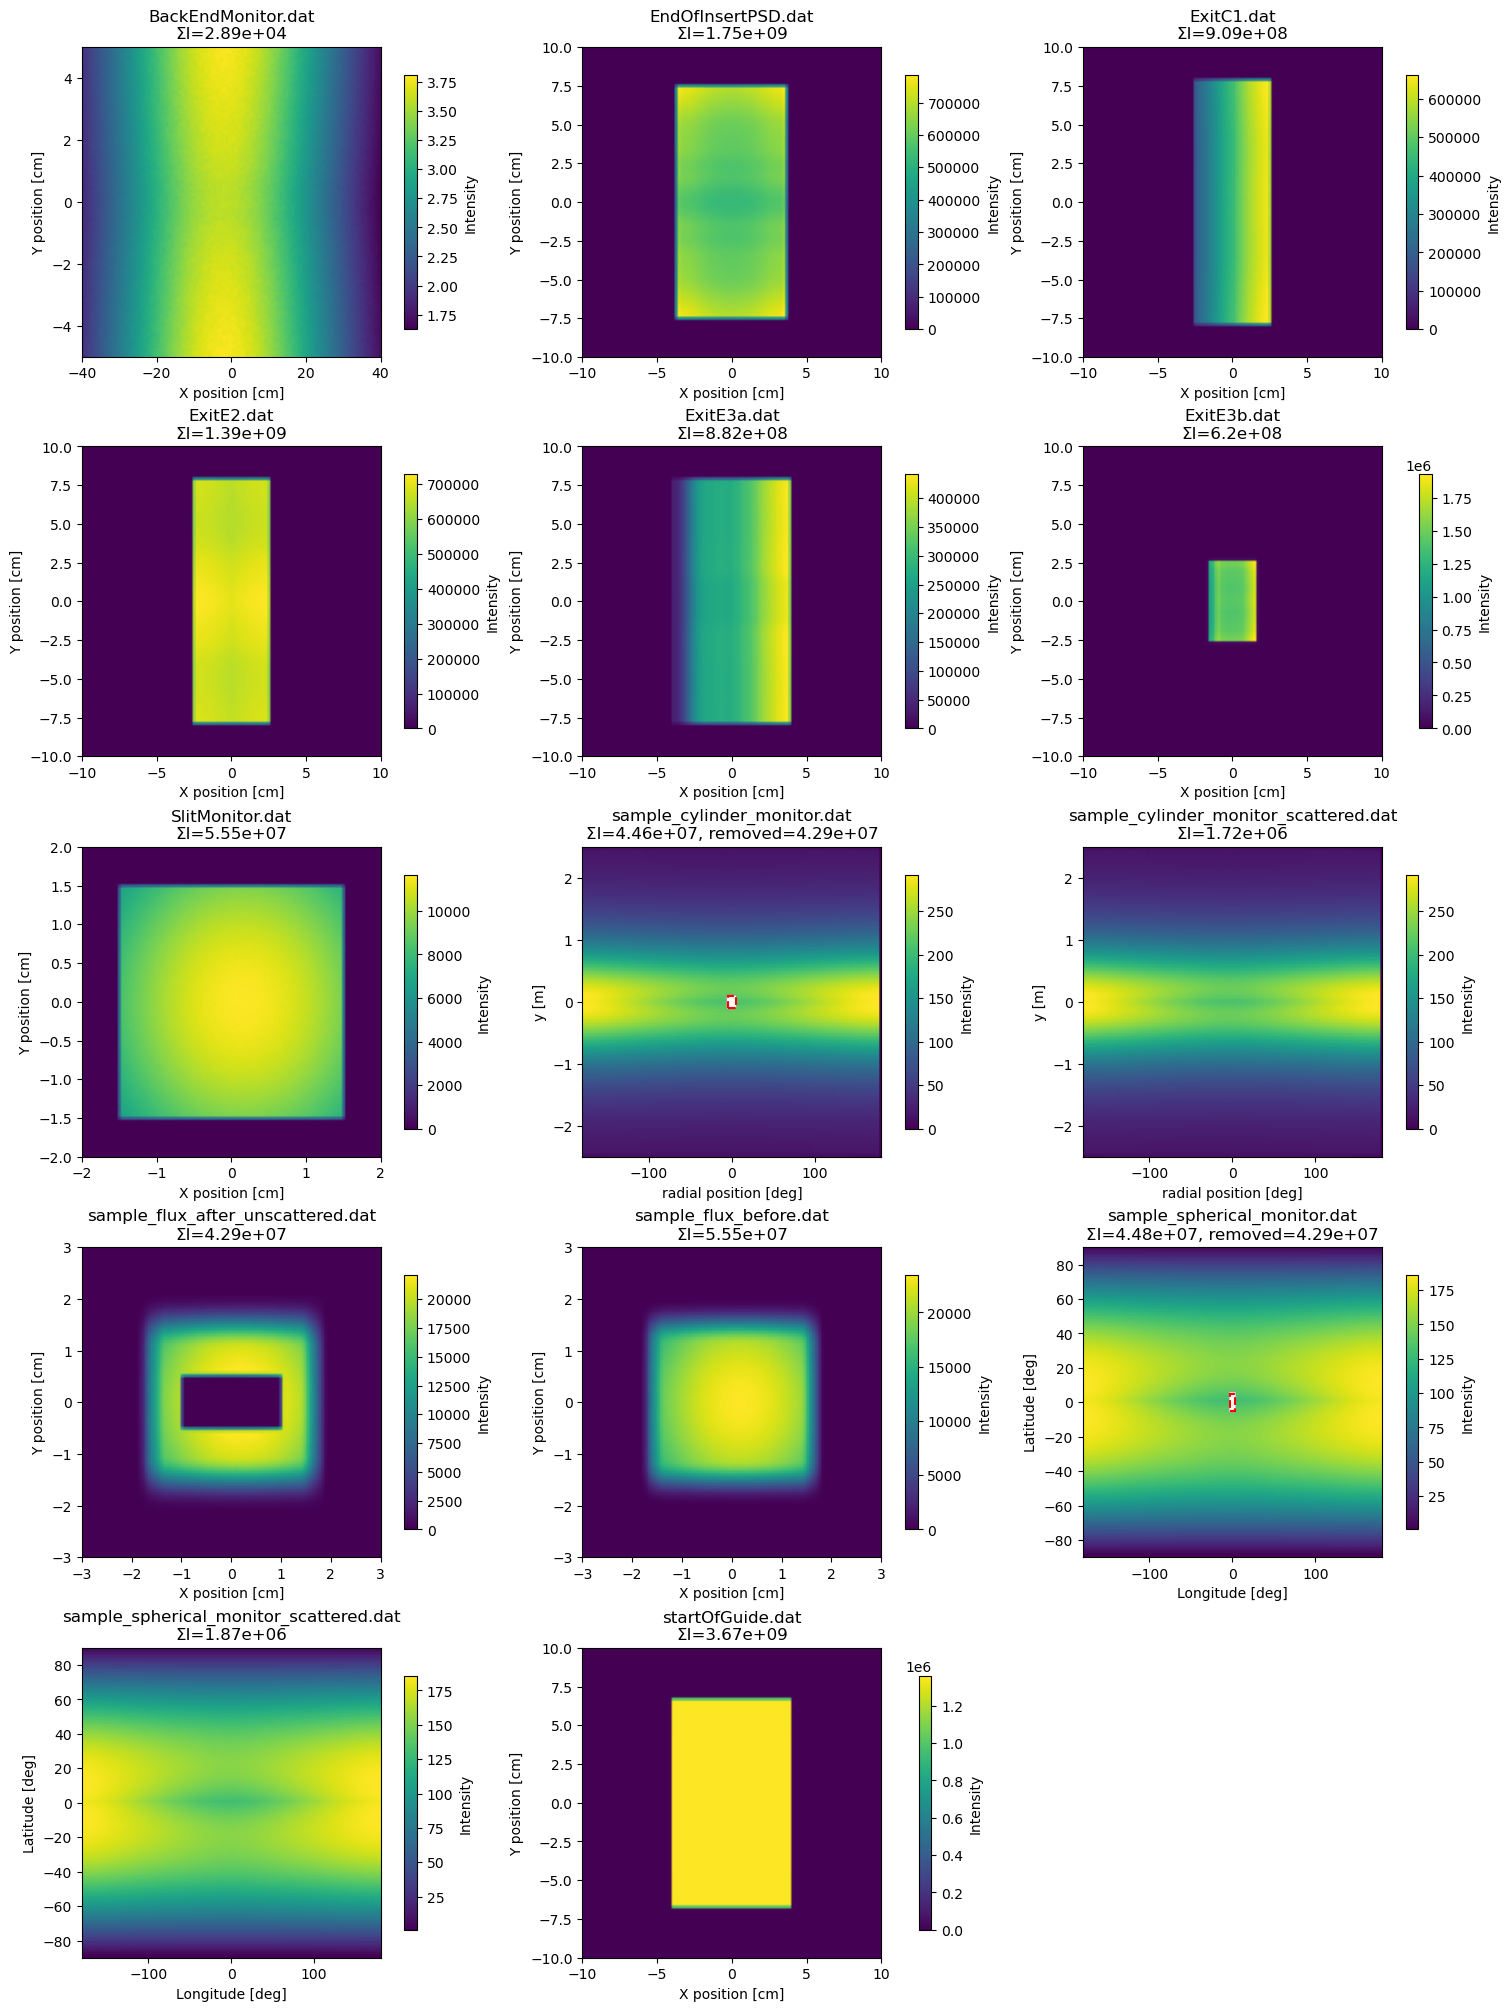

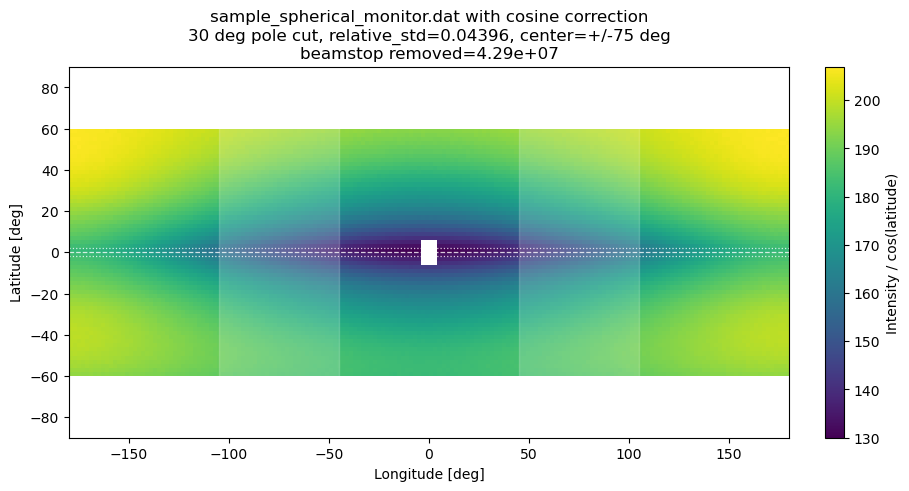

Flattest spherical equator window: center=+/-75 deg, offset=+0 deg, width=60 deg, latitude half-width=2 deg, relative_std=0.0439577, mean=298.532 +/- 0.0144354, sigma=13.1228, sum=18509.015 +/- 0.894993
Anisotropy analysis for selected 60 deg windows:
  combined: n=62, mean=298.532, weighted_mean=297.443, std/mean=0.0439577, peak_to_peak/mean=0.156791, max_dev/mean=0.082544, reduced_chi2=13316.5
  positive: n=31, mean=300.638, weighted_mean=299.541, std/mean=0.0440798, peak_to_peak/mean=0.145638, max_dev/mean=0.0749617, reduced_chi2=13514.2
  negative: n=31, mean=296.427, weighted_mean=295.373, std/mean=0.0433827, peak_to_peak/mean=0.141908, max_dev/mean=0.0742375, reduced_chi2=12863


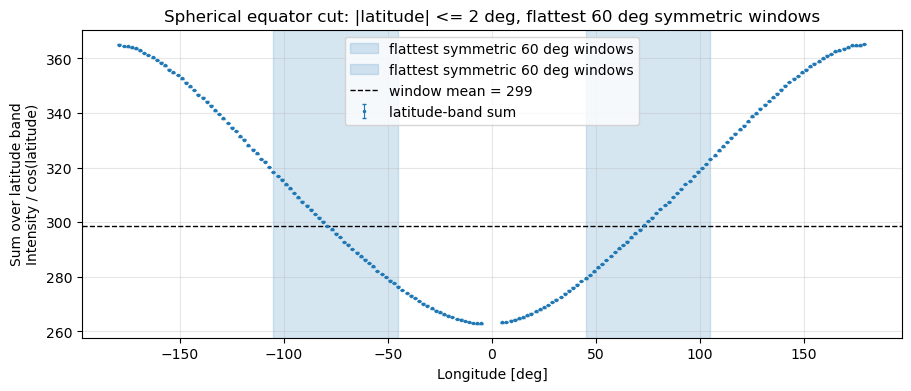

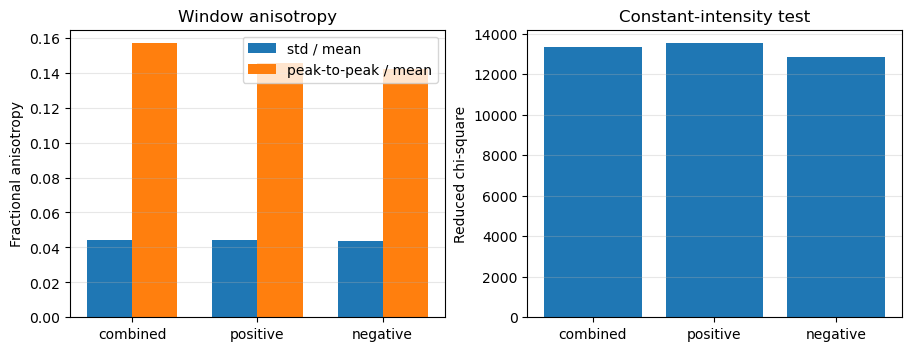

In [90]:
import re
from math import ceil
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

workspace_root = Path('/Users/christian/Documents/Study/bachelor_project')
sample_run_dir = workspace_root / 'geometry_optimization' / 'PSI_instrument' / 'PSI_settings_1e11'
if not sample_run_dir.exists():
    sample_run_dir = Path('geometry_optimization/PSI_instrument/PSI_settings_1e11')

# Beamstop settings for the direct beam in the sample monitors.
# Spherical monitor axes are longitude [deg] and latitude [deg].
# Cylindrical monitor axes are radial position [deg] and y [m].
beamstop_enabled = True
beamstop_center_spherical = (0.0, 0.0)
beamstop_spherical_width_deg = 6.0
beamstop_spherical_height_deg = 10.0
beamstop_center_cylinder = (0.0, 0.0)
beamstop_cylinder_width_deg = 10.0
beamstop_cylinder_height_m = 0.20
beamstop_monitor_names = {'sample_cylinder_monitor', 'sample_spherical_monitor'}
beamstop_show_outline = True

use_full_volume_for_born = True

# Spherical monitor cosine correction.
# Corrects longitude-latitude bins by their projected solid angle factor cos(latitude).
spherical_cosine_correction = True
spherical_cosine_floor = 1e-6
spherical_pole_cut_deg = 30.0

# Equator cut settings for the spherical monitor.
equator_cut_window_center_deg = 0.0
equator_cut_window_width_deg = 60.0
equator_cut_latitude_halfwidth_deg = 2.0
find_flattest_symmetric_window = True
symmetric_window_nominal_center_deg = 75.0
symmetric_window_offset_scan_deg = np.arange(-0.0, 0.1, 1.0)


def _parse_float_tuple(text, n):
    values = text.split(':', 1)[1].split()
    return tuple(float(value) for value in values[:n])


def is_beamstop_monitor(record):
    names = {record['path'].stem, record.get('component', '')}
    return bool(names & beamstop_monitor_names)


def beamstop_parameters(record):
    name = record['path'].stem
    component = record.get('component', '')
    if 'sample_cylinder_monitor' in {name, component}:
        return {
            'center': beamstop_center_cylinder,
            'width': beamstop_cylinder_width_deg,
            'height': beamstop_cylinder_height_m,
            'x_unit': 'deg',
            'y_unit': 'm',
        }
    if 'sample_spherical_monitor' in {name, component}:
        return {
            'center': beamstop_center_spherical,
            'width': beamstop_spherical_width_deg,
            'height': beamstop_spherical_height_deg,
            'x_unit': 'deg',
            'y_unit': 'deg',
        }
    return None


def coordinate_centers(record):
    extent = record.get('xylimits')
    if extent is None:
        return None, None

    x_min, x_max, y_min, y_max = extent
    y_bins, x_bins = record['I'].shape
    x_edges = np.linspace(x_min, x_max, x_bins + 1)
    y_edges = np.linspace(y_min, y_max, y_bins + 1)
    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
    return x_centers, y_centers


def beamstop_mask_for(record):
    params = beamstop_parameters(record)
    if not beamstop_enabled or record.get('kind') != '2d' or params is None:
        return None, None

    x_centers, y_centers = coordinate_centers(record)
    if x_centers is None or y_centers is None:
        return None, None

    center_x, center_y = params['center']
    width = params['width']
    height = params['height']
    x_mask = np.abs(x_centers - center_x) <= width / 2.0
    y_mask = np.abs(y_centers - center_y) <= height / 2.0
    beamstop_mask = np.outer(y_mask, x_mask)

    return beamstop_mask, {
        'removed_pixels': int(np.count_nonzero(beamstop_mask)),
        'x_unit': params['x_unit'],
        'y_unit': params['y_unit'],
        'width': width,
        'height': height,
        'extent': (
            center_x - width / 2.0,
            center_x + width / 2.0,
            center_y - height / 2.0,
            center_y + height / 2.0,
        ),
    }


def apply_beamstop(record, data_key='I'):
    image = np.array(record[data_key], dtype=float, copy=True)
    beamstop_mask, beamstop_info = beamstop_mask_for(record)
    if beamstop_mask is None:
        return np.ma.masked_invalid(image), None

    if data_key == 'I':
        beamstop_info['removed_intensity'] = float(np.nansum(image[beamstop_mask]))
    image[beamstop_mask] = np.nan
    return np.ma.masked_invalid(image), beamstop_info



def cosine_correct_spherical(record, image):
    if not spherical_cosine_correction:
        return image

    extent = record.get('xylimits')
    if extent is None:
        return image

    _, _, lat_min, lat_max = extent
    y_bins = image.shape[0]
    lat_edges = np.linspace(lat_min, lat_max, y_bins + 1)
    lat_centers = 0.5 * (lat_edges[:-1] + lat_edges[1:])
    cos_lat = np.cos(np.deg2rad(lat_centers))
    pole_limit = 90.0 - spherical_pole_cut_deg
    valid = (np.abs(cos_lat) >= spherical_cosine_floor) & (np.abs(lat_centers) <= pole_limit)

    corrected = np.ma.array(image, copy=True)
    corrected[~valid, :] = np.ma.masked
    corrected[valid, :] = corrected[valid, :] / np.abs(cos_lat[valid, None])
    return corrected


def angular_delta_deg(values, center):
    return (values - center + 180.0) % 360.0 - 180.0


def symmetric_window_mask(longitude, center_deg, width_deg):
    half_width = width_deg / 2.0
    positive = np.abs(angular_delta_deg(longitude, center_deg)) <= half_width
    negative = np.abs(angular_delta_deg(longitude, -center_deg)) <= half_width
    return positive | negative


def window_spans(center_deg, width_deg):
    half_width = width_deg / 2.0
    return [
        (center_deg - half_width, center_deg + half_width),
        (-center_deg - half_width, -center_deg + half_width),
    ]


def shade_window_spans(ax, center_deg, width_deg, **kwargs):
    for lo, hi in window_spans(center_deg, width_deg):
        ax.axvspan(lo, hi, **kwargs)


def outline_detector_windows(ax, center_deg, width_deg, height_deg, **kwargs):
    for lo, hi in window_spans(center_deg, width_deg):
        ax.add_patch(Rectangle(
            (lo, -0.5 * height_deg),
            hi - lo,
            height_deg,
            fill=False,
            **kwargs,
        ))


def score_symmetric_window(longitude, profile, profile_error, center_deg, width_deg):
    if abs(center_deg) < width_deg / 2.0:
        return None

    mask = symmetric_window_mask(longitude, center_deg, width_deg)
    values = np.ma.array(profile, copy=False)[mask]
    errors = None if profile_error is None else np.ma.array(profile_error, copy=False)[mask]

    valid = ~np.ma.getmaskarray(values) & np.isfinite(np.asarray(values, dtype=float)) & (np.asarray(values, dtype=float) > 0)
    if np.count_nonzero(valid) < 2:
        return None

    y = np.asarray(values, dtype=float)[valid]
    mean = float(np.mean(y))
    sigma = float(np.std(y, ddof=1))
    relative_std = sigma / mean if mean > 0 else np.nan

    if errors is not None:
        yerr = np.asarray(errors, dtype=float)[valid]
        valid_err = np.isfinite(yerr) & (yerr > 0)
        mean_error = float(np.sqrt(np.sum(yerr[valid_err]**2)) / yerr[valid_err].size) if np.any(valid_err) else np.nan
    else:
        mean_error = np.nan

    if not np.isfinite(relative_std):
        return None

    return {
        'center_deg': center_deg,
        'offset_deg': center_deg - symmetric_window_nominal_center_deg,
        'mask': mask,
        'mean': mean,
        'mean_error': mean_error,
        'sigma': sigma,
        'relative_std': relative_std,
        'n_points': int(y.size),
    }


def anisotropy_stats(longitude, profile, profile_error, mask):
    values_all = np.ma.array(profile, copy=False)[mask]
    errors_all = None if profile_error is None else np.ma.array(profile_error, copy=False)[mask]
    lon_all = np.asarray(longitude)[mask]

    valid = ~np.ma.getmaskarray(values_all) & np.isfinite(np.asarray(values_all, dtype=float)) & (np.asarray(values_all, dtype=float) > 0)
    if np.count_nonzero(valid) < 2:
        return None

    y = np.asarray(values_all, dtype=float)[valid]
    lon = lon_all[valid]
    mean = float(np.mean(y))
    sigma = float(np.std(y, ddof=1))
    minimum = float(np.min(y))
    maximum = float(np.max(y))
    peak_to_peak = maximum - minimum
    peak_to_peak_fraction = peak_to_peak / mean if mean > 0 else np.nan
    max_deviation_fraction = float(np.max(np.abs(y - mean)) / mean) if mean > 0 else np.nan

    if errors_all is not None:
        yerr_all = np.asarray(errors_all, dtype=float)[valid]
        err_valid = np.isfinite(yerr_all) & (yerr_all > 0)
        if np.count_nonzero(err_valid) >= 2:
            y_err = yerr_all[err_valid]
            y_for_chi = y[err_valid]
            weights = 1.0 / y_err**2
            weighted_mean = float(np.sum(weights * y_for_chi) / np.sum(weights))
            chi2 = float(np.sum(((y_for_chi - weighted_mean) / y_err)**2))
            reduced_chi2 = chi2 / (y_for_chi.size - 1)
        else:
            weighted_mean = np.nan
            reduced_chi2 = np.nan
    else:
        weighted_mean = np.nan
        reduced_chi2 = np.nan

    return {
        'longitude': lon,
        'values': y,
        'mean': mean,
        'weighted_mean': weighted_mean,
        'sigma': sigma,
        'relative_std': sigma / mean if mean > 0 else np.nan,
        'min': minimum,
        'max': maximum,
        'peak_to_peak': peak_to_peak,
        'peak_to_peak_fraction': peak_to_peak_fraction,
        'max_deviation_fraction': max_deviation_fraction,
        'reduced_chi2': reduced_chi2,
        'n_points': int(y.size),
    }


def analyze_window_anisotropy(longitude, profile, profile_error, center_deg, width_deg):
    combined_mask = symmetric_window_mask(longitude, center_deg, width_deg)
    pos_mask = np.abs(angular_delta_deg(longitude, center_deg)) <= width_deg / 2.0
    neg_mask = np.abs(angular_delta_deg(longitude, -center_deg)) <= width_deg / 2.0
    return {
        'combined': anisotropy_stats(longitude, profile, profile_error, combined_mask),
        'positive': anisotropy_stats(longitude, profile, profile_error, pos_mask),
        'negative': anisotropy_stats(longitude, profile, profile_error, neg_mask),
    }


def print_anisotropy_report(analysis):
    print('Anisotropy analysis for selected 60 deg windows:')
    for label in ('combined', 'positive', 'negative'):
        stats = analysis.get(label)
        if stats is None:
            print(f'  {label}: not enough valid points')
            continue
        weighted = '' if not np.isfinite(stats['weighted_mean']) else f", weighted_mean={stats['weighted_mean']:.6g}"
        chi2 = '' if not np.isfinite(stats['reduced_chi2']) else f", reduced_chi2={stats['reduced_chi2']:.6g}"
        print(
            f"  {label}: n={stats['n_points']}, mean={stats['mean']:.6g}{weighted}, "
            f"std/mean={stats['relative_std']:.6g}, "
            f"peak_to_peak/mean={stats['peak_to_peak_fraction']:.6g}, "
            f"max_dev/mean={stats['max_deviation_fraction']:.6g}{chi2}"
        )


def find_flattest_window(longitude, profile, profile_error):
    if not find_flattest_symmetric_window:
        return score_symmetric_window(
            longitude,
            profile,
            profile_error,
            equator_cut_window_center_deg,
            equator_cut_window_width_deg,
        )

    scores = []
    for offset_deg in symmetric_window_offset_scan_deg:
        score = score_symmetric_window(
            longitude,
            profile,
            profile_error,
            symmetric_window_nominal_center_deg + offset_deg,
            equator_cut_window_width_deg,
        )
        if score is not None:
            scores.append(score)

    return min(scores, key=lambda item: item['relative_std']) if scores else None


def spherical_equator_cut(record, corrected_image, corrected_error):
    lon_centers, lat_centers = coordinate_centers(record)
    if lon_centers is None or lat_centers is None:
        raise ValueError('Spherical monitor is missing xylimits')

    lat_mask = np.abs(lat_centers) <= equator_cut_latitude_halfwidth_deg
    band = np.ma.array(corrected_image, copy=False)[lat_mask, :]
    profile = np.ma.sum(band, axis=0)

    if corrected_error is None:
        profile_error = None
    else:
        err_band = np.ma.array(corrected_error, copy=False)[lat_mask, :]
        profile_error = np.ma.sqrt(np.ma.sum(err_band**2, axis=0))

    best_window = find_flattest_window(lon_centers, profile, profile_error)
    lon_mask = best_window['mask'] if best_window is not None else np.zeros_like(lon_centers, dtype=bool)

    window_sum = np.ma.sum(profile[lon_mask])
    if profile_error is None:
        window_error = None
    else:
        window_error = np.ma.sqrt(np.ma.sum(profile_error[lon_mask]**2))

    return {
        'longitude': lon_centers,
        'latitude': lat_centers,
        'latitude_mask': lat_mask,
        'longitude_mask': lon_mask,
        'profile': profile,
        'profile_error': profile_error,
        'window_sum': window_sum,
        'window_error': window_error,
        'best_window': best_window,
    }


def parse_mccode_dat(path):
    path = Path(path)
    lines = path.read_text(errors='ignore').splitlines()
    meta = {'path': path}
    monitor_type = None
    nx = None
    ny = None

    for line in lines:
        if line.startswith('# type:'):
            monitor_type = line.split(':', 1)[1].strip()
            dim_match = re.search(r'array_(1d|2d)\(([^)]*)\)', monitor_type)
            if dim_match:
                dims = [int(value.strip()) for value in dim_match.group(2).split(',') if value.strip()]
                nx = dims[0] if dims else None
                ny = dims[1] if len(dims) > 1 else None
        elif line.startswith('# component:'):
            meta['component'] = line.split(':', 1)[1].strip()
        elif line.startswith('# title:'):
            meta['title'] = line.split(':', 1)[1].strip()
        elif line.startswith('# xlabel:'):
            meta['xlabel'] = line.split(':', 1)[1].strip()
        elif line.startswith('# ylabel:'):
            meta['ylabel'] = line.split(':', 1)[1].strip()
        elif line.startswith('# xlimits:'):
            meta['xlimits'] = _parse_float_tuple(line, 2)
        elif line.startswith('# xylimits:'):
            meta['xylimits'] = _parse_float_tuple(line, 4)
        elif line.startswith('# values:'):
            values = [float(value) for value in line.split(':', 1)[1].split()[:3]]
            if values:
                meta['header_total'] = values[0]
                if len(values) > 1:
                    meta['header_error'] = values[1]
                if len(values) > 2:
                    meta['header_counts'] = values[2]

    data_start = None
    for index, line in enumerate(lines):
        if line.startswith('# Data') and line.rstrip().endswith('I:'):
            data_start = index + 1
            break
    if data_start is None:
        raise ValueError(f'Could not find intensity section in {path.name}')

    rows = []
    for line in lines[data_start:]:
        stripped = line.strip()
        if not stripped:
            continue
        if stripped.startswith('#'):
            continue
        rows.append([float(value) for value in stripped.split()])

    if not rows:
        raise ValueError(f'No intensity values found in {path.name}')

    data = np.array(rows, dtype=float)
    if monitor_type and monitor_type.startswith('array_1d'):
        if data.ndim == 2 and data.shape[1] >= 2:
            x = data[:, 0]
            intensity = data[:, 1]
        else:
            intensity = data.reshape(-1)
            limits = meta.get('xlimits')
            x = np.linspace(limits[0], limits[1], intensity.size) if limits else np.arange(intensity.size)
        meta.update({
            'kind': '1d',
            'x': x,
            'I': intensity,
            'total': float(np.nansum(intensity)),
        })
        return meta

    intensity = data[:ny, :] if ny is not None and data.shape[0] >= ny else data
    error = data[ny:2 * ny, :] if ny is not None and data.shape[0] >= 2 * ny else None
    counts = data[2 * ny:3 * ny, :] if ny is not None and data.shape[0] >= 3 * ny else None

    meta.update({
        'kind': '2d',
        'I': intensity,
        'I_err': error,
        'N': counts,
        'total': float(np.nansum(intensity)),
        'shape': intensity.shape,
    })
    return meta


dat_files = sorted(sample_run_dir.glob('*.dat'))
records = []
skipped = []
for dat_file in dat_files:
    try:
        records.append(parse_mccode_dat(dat_file))
    except Exception as exc:
        skipped.append((dat_file, exc))

print(f'Sample run directory: {sample_run_dir}')
print(f'Parsed {len(records)} of {len(dat_files)} .dat files')
if beamstop_enabled:
    print('Beamstop enabled:')
    print(
        '  sample_spherical_monitor: '
        f'{beamstop_spherical_width_deg:g} deg x {beamstop_spherical_height_deg:g} deg '
        f'centered at {beamstop_center_spherical}'
    )
    print(
        '  sample_cylinder_monitor:  '
        f'{beamstop_cylinder_width_deg:g} deg x {beamstop_cylinder_height_m:g} m '
        f'centered at {beamstop_center_cylinder}'
    )
if skipped:
    print('Skipped files:')
    for path, exc in skipped:
        print(f'  {path.name}: {exc}')

if records:
    print('Monitor totals:')
    for record in sorted(records, key=lambda item: item['path'].name.lower()):
        total = record.get('header_total', record['total'])
        component = record.get('component', '')
        print(f"  {record['path'].name:<30} total={total:.6g}  component={component}")

    if beamstop_enabled:
        print('Beamstop masked intensity:')
        for record in sorted(records, key=lambda item: item['path'].name.lower()):
            _, beamstop_info = apply_beamstop(record)
            if beamstop_info is not None:
                print(
                    f"  {record['path'].name:<30} "
                    f"removed={beamstop_info['removed_intensity']:.6g} "
                    f"pixels={beamstop_info['removed_pixels']} "
                    f"size={beamstop_info['width']:g} {beamstop_info['x_unit']} x "
                    f"{beamstop_info['height']:g} {beamstop_info['y_unit']}"
                )

    fig, ax = plt.subplots(figsize=(max(8, 0.55 * len(records)), 4))
    ordered = sorted(records, key=lambda item: item.get('header_total', item['total']), reverse=True)
    names = [record['path'].stem for record in ordered]
    totals = [record.get('header_total', record['total']) for record in ordered]
    ax.bar(names, totals)
    ax.set_yscale('log')
    ax.set_ylabel('Integrated intensity')
    ax.set_title('sample_run_2e8n monitor totals')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

two_d_records = [record for record in records if record['kind'] == '2d']
if two_d_records:
    ncols = min(3, len(two_d_records))
    nrows = ceil(len(two_d_records) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.0 * ncols, 4.0 * nrows), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, record in zip(axes, two_d_records):
        image, beamstop_info = apply_beamstop(record)
        extent = record.get('xylimits')
        im = ax.imshow(image, origin='lower', aspect='auto', extent=extent, cmap='viridis')
        total = record.get('header_total', record['total'])
        title = f"{record['path'].name}\nΣI={total:.3g}"
        if beamstop_info is not None:
            title += f", removed={beamstop_info['removed_intensity']:.3g}"
            if beamstop_show_outline:
                x0, x1, y0, y1 = beamstop_info['extent']
                ax.add_patch(Rectangle(
                    (x0, y0),
                    x1 - x0,
                    y1 - y0,
                    fill=False,
                    edgecolor='red',
                    linewidth=1.5,
                    linestyle='--',
                ))
        ax.set_title(title)
        ax.set_xlabel(record.get('xlabel', 'x'))
        ax.set_ylabel(record.get('ylabel', 'y'))
        fig.colorbar(im, ax=ax, shrink=0.82, label='Intensity')

    for ax in axes[len(two_d_records):]:
        ax.axis('off')
    plt.show()

spherical_records = [
    record for record in two_d_records
    if record['path'].stem == 'sample_spherical_monitor' or record.get('component') == 'sample_spherical_monitor'
]
for record in spherical_records:
    image, beamstop_info = apply_beamstop(record)
    corrected_image = cosine_correct_spherical(record, image)
    extent = record.get('xylimits')

    corrected_error = None
    if record.get('I_err') is not None:
        error_image, _ = apply_beamstop(record, data_key='I_err')
        corrected_error = cosine_correct_spherical(record, error_image)

    cut = spherical_equator_cut(record, corrected_image, corrected_error)
    best_window = cut['best_window']

    fig, ax = plt.subplots(figsize=(9, 4.8), constrained_layout=True)
    im = ax.imshow(corrected_image, origin='lower', aspect='auto', extent=extent, cmap='viridis')
    title = f"{record['path'].name} with cosine correction\n{int(spherical_pole_cut_deg) if spherical_pole_cut_deg.is_integer() else spherical_pole_cut_deg:g} deg pole cut"
    if best_window is not None:
        title += f", relative_std={best_window['relative_std']:.4g}, center=+/-{best_window['center_deg']:g} deg"
        shade_window_spans(
            ax,
            best_window['center_deg'],
            equator_cut_window_width_deg,
            alpha=0.18,
            color='white',
        )
    ax.axhline(0.0, color='white', linestyle='--', linewidth=0.9, alpha=0.8)
    ax.axhline(equator_cut_latitude_halfwidth_deg, color='white', linestyle=':', linewidth=0.9, alpha=0.8)
    ax.axhline(-equator_cut_latitude_halfwidth_deg, color='white', linestyle=':', linewidth=0.9, alpha=0.8)
    if beamstop_info is not None:
        title += f"\nbeamstop removed={beamstop_info['removed_intensity']:.3g}"
    ax.set_title(title)
    ax.set_xlabel(record.get('xlabel', 'Longitude [deg]'))
    ax.set_ylabel(record.get('ylabel', 'Latitude [deg]'))
    fig.colorbar(im, ax=ax, label='Intensity / cos(latitude)')
    plt.show()

    window_sum = cut['window_sum']
    window_error = cut['window_error']
    if best_window is not None:
        print(
            'Flattest spherical equator window: '
            f'center=+/-{best_window["center_deg"]:g} deg, '
            f'offset={best_window["offset_deg"]:+g} deg, '
            f'width={equator_cut_window_width_deg:g} deg, '
            f'latitude half-width={equator_cut_latitude_halfwidth_deg:g} deg, '
            f'relative_std={best_window["relative_std"]:.6g}, '
            f'mean={best_window["mean"]:.6g}'
            + (f' +/- {best_window["mean_error"]:.6g}' if np.isfinite(best_window['mean_error']) else '')
            + f', sigma={best_window["sigma"]:.6g}, '
            f'sum={float(window_sum):.8g}'
            + (f' +/- {float(window_error):.6g}' if window_error is not None else '')
        )

    anisotropy = None
    if best_window is not None:
        anisotropy = analyze_window_anisotropy(
            cut['longitude'],
            cut['profile'],
            cut['profile_error'],
            best_window['center_deg'],
            equator_cut_window_width_deg,
        )
        print_anisotropy_report(anisotropy)

    fig, ax = plt.subplots(figsize=(9, 3.8), constrained_layout=True)
    if cut['profile_error'] is not None:
        ax.errorbar(
            cut['longitude'],
            cut['profile'],
            yerr=cut['profile_error'],
            fmt='.',
            markersize=3,
            linewidth=0.8,
            capsize=1.5,
            label='latitude-band sum',
        )
    else:
        ax.plot(cut['longitude'], cut['profile'], '.', markersize=3, label='latitude-band sum')

    if best_window is not None:
        shade_window_spans(
            ax,
            best_window['center_deg'],
            equator_cut_window_width_deg,
            alpha=0.18,
            color='tab:blue',
            label='flattest symmetric 60 deg windows',
        )
        ax.axhline(
            best_window['mean'],
            color='black',
            linestyle='--',
            linewidth=1.0,
            label=f"window mean = {best_window['mean']:.3g}",
        )
    ax.set_title(
        f'Spherical equator cut: |latitude| <= {equator_cut_latitude_halfwidth_deg:g} deg, '
        f'flattest {equator_cut_window_width_deg:g} deg symmetric windows'
    )
    ax.set_xlabel('Longitude [deg]')
    ax.set_ylabel('Sum over latitude band\nIntensity / cos(latitude)')
    ax.grid(alpha=0.3)
    ax.legend(loc='best')
    plt.show()

    if anisotropy is not None:
        labels = []
        rel_std_values = []
        peak_values = []
        chi2_values = []
        for label in ('combined', 'positive', 'negative'):
            stats = anisotropy.get(label)
            if stats is None:
                continue
            labels.append(label)
            rel_std_values.append(stats['relative_std'])
            peak_values.append(stats['peak_to_peak_fraction'])
            chi2_values.append(stats['reduced_chi2'])

        x = np.arange(len(labels))
        fig, axes = plt.subplots(1, 2, figsize=(9, 3.4), constrained_layout=True)
        axes[0].bar(x - 0.18, rel_std_values, width=0.36, label='std / mean')
        axes[0].bar(x + 0.18, peak_values, width=0.36, label='peak-to-peak / mean')
        axes[0].set_xticks(x, labels)
        axes[0].set_ylabel('Fractional anisotropy')
        axes[0].set_title('Window anisotropy')
        axes[0].grid(axis='y', alpha=0.3)
        axes[0].legend()

        finite_chi2 = np.isfinite(chi2_values)
        if np.any(finite_chi2):
            axes[1].bar(np.asarray(labels)[finite_chi2], np.asarray(chi2_values)[finite_chi2])
            axes[1].set_ylabel('Reduced chi-square')
            axes[1].set_title('Constant-intensity test')
            axes[1].grid(axis='y', alpha=0.3)
        else:
            axes[1].axis('off')
        plt.show()

one_d_records = [record for record in records if record['kind'] == '1d']
if one_d_records:
    ncols = min(2, len(one_d_records))
    nrows = ceil(len(one_d_records) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.0 * ncols, 3.5 * nrows), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, record in zip(axes, one_d_records):
        ax.plot(record['x'], record['I'])
        ax.set_title(record['path'].name)
        ax.set_xlabel(record.get('xlabel', 'x'))
        ax.set_ylabel('Intensity')
        ax.grid(alpha=0.3)

    for ax in axes[len(one_d_records):]:
        ax.axis('off')
    plt.show()



















Born expected intensity for PSI sample
  spherical monitor: sample_spherical_monitor_scattered.dat
  intensity hitting sample: 1.26151e+07 +/- 1214.68
  hit intensity method: sample_flux_before.dat - sample_flux_after_unscattered.dat
  flux before sample: 5.55197e+07
  flux after sample, unscattered: 4.29046e+07
  sample geometry: R=1 cm, H=1 cm, t=0.26 cm
  Born probability mode: beam_weighted
  include lids in Born path map: True
  side-wall volume: 1.42126 cm^3
  lid volume used: 1.63363 cm^3
  material volume used: 3.05488 cm^3
  V/A_proj mean path length: 1.52744 cm
  probability path method: beam weighted from sample_flux_before.dat
  probability mean path length: 1.47497 cm
  interaction probability: 0.295256
  latitude-band solid angle per longitude bin: 0.00243682 sr
  expected intensity per longitude bin: 722.274
  observed window mean: 298.532 +/- 0.0144354
  observed / expected: 0.413323
  expected window sum: 44781
  observed window sum: 18509


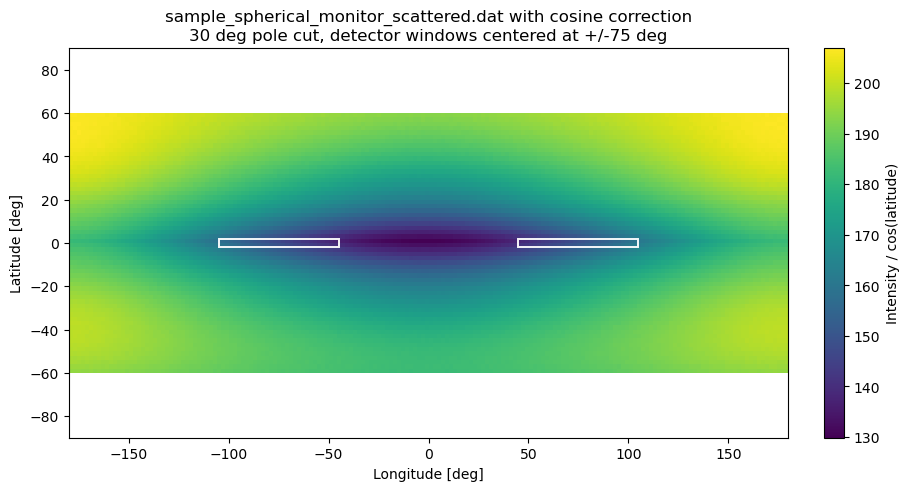

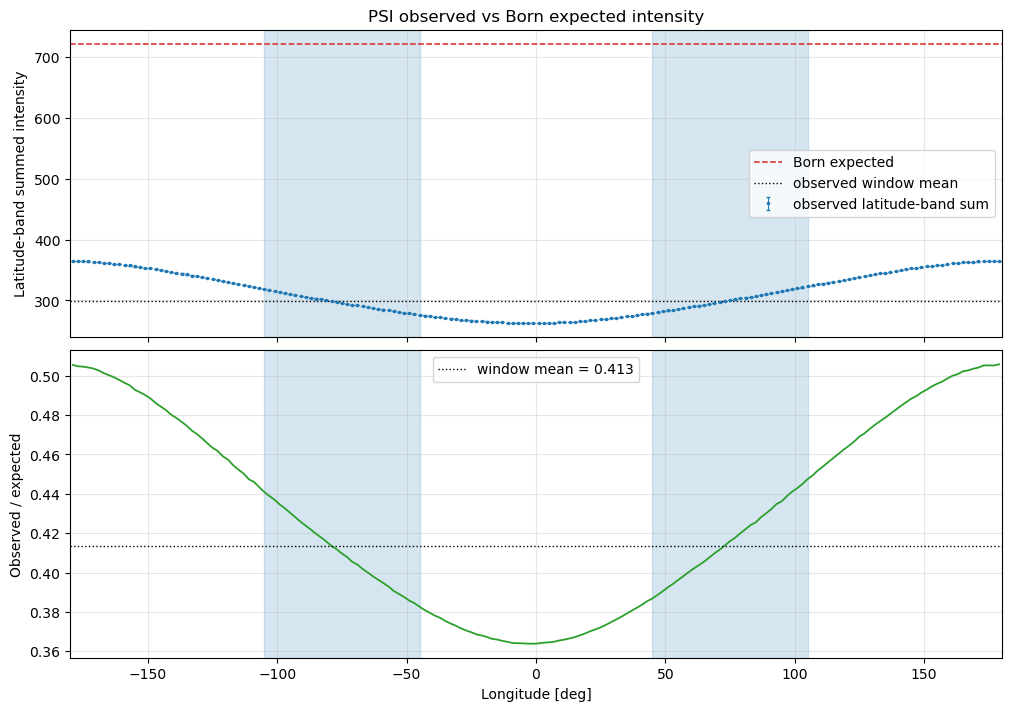

In [91]:
# ============================================================
# Born expected intensity for the PSI sample
# ============================================================
# Mirrors the self_absorption.ipynb convention:
#   intensity_hitting_sample = before - after
#   expected = intensity_hitting_sample * P_interact * solid_angle / (4*pi)
# with either P_interact = Sigma_inc * L_mean or
# P_interact = (1 - exp(-Sigma_total * L_mean)) * Sigma_inc / Sigma_total.
# where L_mean = material volume / projected area.

psi_sigma_inc_cm_inv = 0.367
psi_sigma_abs_cm_inv = psi_sigma_inc_cm_inv
psi_sigma_coh_cm_inv = 1.786e-3
psi_sigma_s_cm_inv = psi_sigma_inc_cm_inv + psi_sigma_coh_cm_inv
psi_sigma_total_cm_inv = psi_sigma_inc_cm_inv + psi_sigma_coh_cm_inv + psi_sigma_abs_cm_inv
# Options: 'mean_path_exponential', 'mean_path_linear', or 'beam_weighted'.
psi_born_probability_mode = 'beam_weighted'
# Used by the mean-path modes and by the beam-weighted path-length map.
# False keeps the old side-wall-only Born path length. True includes end-cap material.
psi_include_lids_for_born = True

psi_preferred_spherical_monitors = (
    'sample_spherical_monitor_scattered',
    'sample_spherical_monitor',
)


def parse_mccode_params(sim_file):
    sim_file = Path(sim_file)
    params = {}
    pattern = re.compile(r'^\s*#?\s*Param:\s*([A-Za-z0-9_]+)=(.+?)\s*$')
    with sim_file.open('r') as f:
        for line in f:
            match = pattern.match(line)
            if not match:
                continue
            key = match.group(1).strip()
            raw_value = match.group(2).strip()
            try:
                params[key] = float(raw_value)
            except ValueError:
                pass
    return params


def record_by_name(records, names):
    wanted = set(names)
    for record in records:
        record_names = {record['path'].stem, record.get('component', '')}
        if record_names & wanted:
            return record
    return None


def record_total(record):
    return float(record.get('header_total', record['total']))


def record_total_error(record):
    if record.get('header_error') is not None:
        return float(record['header_error'])
    if record.get('I_err') is not None:
        return float(np.sqrt(np.nansum(np.asarray(record['I_err'], dtype=float)**2)))
    return np.nan


def sum_record_in_rectangle(record, x_min, x_max, y_min, y_max):
    x_centers, y_centers = coordinate_centers(record)
    if x_centers is None or y_centers is None:
        raise ValueError(f"{record['path'].name} is missing xylimits")
    mask = np.outer((y_centers >= y_min) & (y_centers <= y_max), (x_centers >= x_min) & (x_centers <= x_max))
    intensity = np.asarray(record['I'], dtype=float)
    total = float(np.nansum(intensity[mask]))
    if record.get('I_err') is None:
        error = np.nan
    else:
        error = float(np.sqrt(np.nansum(np.asarray(record['I_err'], dtype=float)[mask]**2)))
    return total, error


def psi_geometry_cm(run_dir):
    params = parse_mccode_params(Path(run_dir) / 'mccode.sim')
    missing = [key for key in ('sampleRadius', 'sampleHeight', 'sampleThickness') if key not in params]
    if missing:
        raise ValueError(f'Missing {missing} in {Path(run_dir) / "mccode.sim"}')
    return {
        'outer_radius_cm': params['sampleRadius'] * 100.0,
        'outer_height_cm': params['sampleHeight'] * 100.0,
        'wall_thickness_cm': params['sampleThickness'] * 100.0,
    }


def psi_side_wall_volume_cm3(geometry):
    R = geometry['outer_radius_cm']
    H = geometry['outer_height_cm']
    t = geometry['wall_thickness_cm']
    r = R - t
    if r <= 0:
        return np.nan
    return np.pi * (R**2 - r**2) * H


def psi_lid_volume_cm3(geometry):
    R = geometry['outer_radius_cm']
    t = geometry['wall_thickness_cm']
    if t <= 0:
        return 0.0
    return 2.0 * np.pi * R**2 * t


def psi_material_volume_cm3(geometry):
    volume = psi_side_wall_volume_cm3(geometry)
    if psi_include_lids_for_born:
        volume += psi_lid_volume_cm3(geometry)
    return volume


def psi_projected_area_cm2(geometry):
    return 2.0 * geometry['outer_radius_cm'] * geometry['outer_height_cm']


def psi_mean_path_length_cm(geometry):
    return psi_material_volume_cm3(geometry) / psi_projected_area_cm2(geometry)


def psi_probability_from_path_length_cm(path_length_cm):
    path_length_cm = np.asarray(path_length_cm, dtype=float)
    if psi_born_probability_mode == 'mean_path_linear':
        return psi_sigma_inc_cm_inv * path_length_cm
    if psi_sigma_total_cm_inv <= 0:
        return np.zeros_like(path_length_cm, dtype=float)
    total_interaction_probability = 1.0 - np.exp(-psi_sigma_total_cm_inv * path_length_cm)
    return total_interaction_probability * psi_sigma_inc_cm_inv / psi_sigma_total_cm_inv


def psi_interaction_probability_from_mean_path(geometry):
    return float(psi_probability_from_path_length_cm(psi_mean_path_length_cm(geometry)))


def psi_beam_path_length_map_cm(record, geometry):
    x_centers, y_centers = coordinate_centers(record)
    if x_centers is None or y_centers is None:
        raise ValueError(f"{record['path'].name} is missing xylimits for beam-weighted Born estimate")

    x = np.asarray(x_centers, dtype=float)
    y = np.asarray(y_centers, dtype=float)
    R = geometry['outer_radius_cm']
    H = geometry['outer_height_cm']
    t = geometry['wall_thickness_cm']
    r = max(R - t, 0.0)

    outer_chord = np.zeros_like(x, dtype=float)
    outer_mask = np.abs(x) <= R
    outer_chord[outer_mask] = 2.0 * np.sqrt(np.maximum(R**2 - x[outer_mask]**2, 0.0))

    inner_chord = np.zeros_like(x, dtype=float)
    inner_mask = np.abs(x) <= r
    inner_chord[inner_mask] = 2.0 * np.sqrt(np.maximum(r**2 - x[inner_mask]**2, 0.0))

    side_path = outer_chord - inner_chord
    in_height = np.abs(y) <= 0.5 * H
    path = np.outer(in_height.astype(float), side_path)

    if psi_include_lids_for_born and t > 0.0:
        in_lid = (np.abs(y) >= 0.5 * H - t) & (np.abs(y) <= 0.5 * H)
        path += np.outer(in_lid.astype(float), outer_chord)

    return path


def psi_beam_weighted_interaction_probability(records, geometry):
    before = record_by_name(records, ('sample_flux_before', 'before'))
    if before is None:
        before = record_by_name(records, ('sample_flux_before_fullbeam', 'SlitMonitor'))
    if before is None:
        raise FileNotFoundError('Beam-weighted Born estimate needs sample_flux_before or sample_flux_before_fullbeam.')

    intensity = np.asarray(before['I'], dtype=float)
    path = psi_beam_path_length_map_cm(before, geometry)
    in_sample = path > 0.0
    weights = np.where(in_sample & np.isfinite(intensity), intensity, 0.0)
    total_weight = np.nansum(weights)
    if total_weight <= 0.0:
        return {
            'probability': 0.0,
            'mean_path_cm': np.nan,
            'flux_weight': 0.0,
            'method': f"beam weighted from {before['path'].name}, no illuminated sample pixels",
        }

    local_probability = psi_probability_from_path_length_cm(path)
    probability = float(np.nansum(weights * local_probability) / total_weight)
    mean_path = float(np.nansum(weights * path) / total_weight)
    return {
        'probability': probability,
        'mean_path_cm': mean_path,
        'flux_weight': float(total_weight),
        'method': f"beam weighted from {before['path'].name}",
    }


def psi_interaction_probability(geometry, records=None):
    if psi_born_probability_mode == 'beam_weighted':
        if records is None:
            raise ValueError('records are required for psi_born_probability_mode=beam_weighted')
        return psi_beam_weighted_interaction_probability(records, geometry)
    if psi_born_probability_mode not in {'mean_path_exponential', 'mean_path_linear'}:
        raise ValueError(f'Unknown psi_born_probability_mode: {psi_born_probability_mode!r}')
    return {
        'probability': psi_interaction_probability_from_mean_path(geometry),
        'mean_path_cm': psi_mean_path_length_cm(geometry),
        'flux_weight': np.nan,
        'method': psi_born_probability_mode,
    }


def psi_intensity_hitting_sample(records, geometry):
    before = record_by_name(records, ('sample_flux_before', 'before'))
    after = record_by_name(records, ('sample_flux_after_unscattered', 'after'))
    if before is not None and after is not None:
        before_total = record_total(before)
        after_total = record_total(after)
        before_error = record_total_error(before)
        after_error = record_total_error(after)
        error = np.sqrt(before_error**2 + after_error**2) if np.isfinite(before_error) and np.isfinite(after_error) else np.nan
        return {
            'intensity': before_total - after_total,
            'error': error,
            'method': f"{before['path'].name} - {after['path'].name}",
            'before': before_total,
            'after': after_total,
        }

    direct = record_by_name(records, ('sample_flux_hitting_sample',))
    if direct is not None:
        return {
            'intensity': record_total(direct),
            'error': record_total_error(direct),
            'method': direct['path'].name,
            'before': np.nan,
            'after': np.nan,
        }

    # Fallback for older PSI runs before the dedicated sample-flux monitors existed.
    # The monitor coordinates are in cm for PSD monitors.
    fallback = record_by_name(records, ('sample_flux_before_fullbeam', 'SlitMonitor'))
    if fallback is None:
        raise FileNotFoundError(
            'No sample flux monitor found. Rerun the PSI instrument with sample_flux_before and '
            'sample_flux_after_unscattered, or with sample_flux_hitting_sample.'
        )
    R = geometry['outer_radius_cm']
    H = geometry['outer_height_cm']
    total, error = sum_record_in_rectangle(fallback, -R, R, -0.5 * H, 0.5 * H)
    return {
        'intensity': total,
        'error': error,
        'method': f'{fallback["path"].name} integrated over projected sample area (fallback)',
        'before': np.nan,
        'after': np.nan,
    }


def selected_spherical_record(records):
    for name in psi_preferred_spherical_monitors:
        record = record_by_name(records, (name,))
        if record is not None:
            return record
    return None


def corrected_band_solid_angle_per_longitude_sr(record, latitude_mask):
    x_min, x_max, y_min, y_max = record['xylimits']
    n_lat, n_lon = record['I'].shape
    dlon = np.deg2rad((x_max - x_min) / n_lon)
    lat_edges = np.linspace(y_min, y_max, n_lat + 1)
    lat_centers = 0.5 * (lat_edges[:-1] + lat_edges[1:])

    omega = 0.0
    for i, use_bin in enumerate(latitude_mask):
        if not use_bin:
            continue
        lat1 = np.deg2rad(lat_edges[i])
        lat2 = np.deg2rad(lat_edges[i + 1])
        bin_omega = dlon * (np.sin(lat2) - np.sin(lat1))
        if spherical_cosine_correction:
            cos_lat = np.cos(np.deg2rad(lat_centers[i]))
            if abs(cos_lat) < spherical_cosine_floor:
                continue
            bin_omega /= cos_lat
        omega += bin_omega
    return float(omega)


def psi_expected_intensity_per_longitude_bin(run_dir, records, spherical_record, cut):
    geometry = psi_geometry_cm(run_dir)
    hit = psi_intensity_hitting_sample(records, geometry)
    probability_info = psi_interaction_probability(geometry, records)
    probability = probability_info['probability']
    solid_angle = corrected_band_solid_angle_per_longitude_sr(
        spherical_record,
        cut['latitude_mask']
    )
    expected = hit['intensity'] * probability * solid_angle / (4.0 * np.pi)

    if 'fallback' in hit['method']:
        print(
            'WARNING: I_hit is estimated from a fallback SlitMonitor integration, '
            'not from before-after sample flux monitors.'
        )

    return {
        'geometry': geometry,
        'hit': hit,
        'probability': probability,
        'probability_info': probability_info,
        'side_wall_volume_cm3': psi_side_wall_volume_cm3(geometry),
        'lid_volume_cm3': psi_lid_volume_cm3(geometry) if psi_include_lids_for_born else 0.0,
        'material_volume_cm3': psi_material_volume_cm3(geometry),
        'solid_angle': solid_angle,
        'expected_per_longitude_bin': expected,
    }


spherical_record = selected_spherical_record(records)
if spherical_record is None:
    print('No spherical sample monitor found for Born comparison.')
else:
    image, beamstop_info = apply_beamstop(spherical_record)
    corrected_image = cosine_correct_spherical(spherical_record, image)
    corrected_error = None
    if spherical_record.get('I_err') is not None:
        error_image, _ = apply_beamstop(spherical_record, data_key='I_err')
        corrected_error = cosine_correct_spherical(spherical_record, error_image)

    cut = spherical_equator_cut(spherical_record, corrected_image, corrected_error)
    best_window = cut['best_window']
    born = psi_expected_intensity_per_longitude_bin(
    sample_run_dir,
    records,
    spherical_record,
    cut
)

    print('Born expected intensity for PSI sample')
    print(f"  spherical monitor: {spherical_record['path'].name}")
    print(f"  intensity hitting sample: {born['hit']['intensity']:.6g}" + (f" +/- {born['hit']['error']:.6g}" if np.isfinite(born['hit']['error']) else ''))
    print(f"  hit intensity method: {born['hit']['method']}")
    if np.isfinite(born['hit']['before']) and np.isfinite(born['hit']['after']):
        print(f"  flux before sample: {born['hit']['before']:.6g}")
        print(f"  flux after sample, unscattered: {born['hit']['after']:.6g}")
    print(
        '  sample geometry: '
        f"R={born['geometry']['outer_radius_cm']:.4g} cm, "
        f"H={born['geometry']['outer_height_cm']:.4g} cm, "
        f"t={born['geometry']['wall_thickness_cm']:.4g} cm"
    )
    print(f"  Born probability mode: {psi_born_probability_mode}")
    print(f"  include lids in Born path map: {psi_include_lids_for_born}")
    print(f"  side-wall volume: {born['side_wall_volume_cm3']:.6g} cm^3")
    print(f"  lid volume used: {born['lid_volume_cm3']:.6g} cm^3")
    print(f"  material volume used: {born['material_volume_cm3']:.6g} cm^3")
    print(f"  V/A_proj mean path length: {psi_mean_path_length_cm(born['geometry']):.6g} cm")
    print(f"  probability path method: {born['probability_info']['method']}")
    print(f"  probability mean path length: {born['probability_info']['mean_path_cm']:.6g} cm")
    print(f"  interaction probability: {born['probability']:.6g}")
    print(f"  latitude-band solid angle per longitude bin: {born['solid_angle']:.6g} sr")
    print(f"  expected intensity per longitude bin: {born['expected_per_longitude_bin']:.6g}")

    if best_window is not None:
        observed_mean = float(best_window['mean'])
        observed_error = float(best_window['mean_error']) if np.isfinite(best_window['mean_error']) else np.nan
        expected = born['expected_per_longitude_bin']
        ratio = observed_mean / expected if expected > 0 else np.nan
        print(f"  observed window mean: {observed_mean:.6g}" + (f" +/- {observed_error:.6g}" if np.isfinite(observed_error) else ''))
        print(f"  observed / expected: {ratio:.6g}")
        print(f"  expected window sum: {expected * np.count_nonzero(cut['longitude_mask']):.6g}")
        print(f"  observed window sum: {float(cut['window_sum']):.6g}")

        profile = np.ma.asarray(cut['profile'], dtype=float)
        longitude = np.asarray(cut['longitude'], dtype=float)
        valid = ~np.ma.getmaskarray(profile) & np.isfinite(np.ma.filled(profile, np.nan))
        profile_values = np.ma.filled(profile, np.nan)
        ratio_values = np.full_like(profile_values, np.nan, dtype=float)
        if expected > 0:
            ratio_values[valid] = profile_values[valid] / expected

        fig, ax = plt.subplots(figsize=(9, 4.8), constrained_layout=True)
        im = ax.imshow(
            corrected_image,
            origin='lower',
            aspect='auto',
            extent=spherical_record.get('xylimits'),
            cmap='viridis',
        )
        heatmap_title = (
            f"{spherical_record['path'].name} with cosine correction\n"
            f"{spherical_pole_cut_deg:g} deg pole cut"
        )
        if best_window is not None:
            heatmap_title += f", detector windows centered at +/-{best_window['center_deg']:g} deg"
            outline_detector_windows(
                ax,
                best_window['center_deg'],
                equator_cut_window_width_deg,
                2.0 * equator_cut_latitude_halfwidth_deg,
                edgecolor='white',
                linewidth=1.4,
                linestyle='-',
                alpha=0.95,
            )
        if beamstop_info is not None:
            heatmap_title += f"\nbeamstop removed={beamstop_info['removed_intensity']:.3g}"
            heatmap_title += f"\n|phi| <= {equator_cut_latitude_halfwidth_deg:.3g}"  # absolute value of phi for summed latitude band
        ax.set_title(heatmap_title)
        ax.set_xlabel(spherical_record.get('xlabel', 'Longitude [deg]'))
        ax.set_ylabel(spherical_record.get('ylabel', 'Latitude [deg]'))
        fig.colorbar(im, ax=ax, label='Intensity / cos(latitude)')
        plt.show()

        fig, axs = plt.subplots(2, 1, figsize=(10, 7), sharex=True, constrained_layout=True)
        if cut['profile_error'] is not None:
            axs[0].errorbar(
                longitude[valid],
                profile_values[valid],
                yerr=np.ma.filled(cut['profile_error'], np.nan)[valid],
                fmt='.',
                markersize=3,
                linewidth=0.8,
                capsize=1.5,
                label='observed latitude-band sum',
            )
        else:
            axs[0].plot(longitude[valid], profile_values[valid], '.', markersize=3, label='observed latitude-band sum')
        shade_window_spans(axs[0], best_window['center_deg'], equator_cut_window_width_deg, alpha=0.18, color='tab:blue')
        axs[0].axhline(expected, color='tab:red', linestyle='--', linewidth=1.1, label='Born expected')
        axs[0].axhline(observed_mean, color='black', linestyle=':', linewidth=1.0, label='observed window mean')
        axs[0].set_title('PSI observed vs Born expected intensity')
        axs[0].set_ylabel('Latitude-band summed intensity')
        axs[0].grid(True, alpha=0.3)
        axs[0].legend(loc='best')

        axs[1].plot(longitude[valid], ratio_values[valid], color='tab:green', lw=1.3)
        shade_window_spans(axs[1], best_window['center_deg'], equator_cut_window_width_deg, alpha=0.18, color='tab:blue')
        axs[1].axhline(ratio, color='black', linestyle=':', linewidth=1.0, label=f'window mean = {ratio:.3g}')
        axs[1].set_xlabel('Longitude [deg]')
        axs[1].set_ylabel('Observed / expected')
        axs[1].set_xlim(-180, 180)
        axs[1].grid(True, alpha=0.3)
        axs[1].legend(loc='best')
        plt.show()


